In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange, einsum

In [2]:
class RoPE(nn.Module):
    def __init__(self, d: int, base: float = 10000):
        super().__init__()
        self.d = d
        self.base = base

        angles = torch.empty(d)
        for i in range(d // 2):
            angles[2 * i] = base ** (-2 * i / d)
            angles[2 * i + 1] = base ** (-2 * i / d)

        self.register_buffer("angles", angles)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, h, l, d = x.size()

        position_angles = einsum(torch.arange(l), self.angles, "t, d -> t d").unsqueeze(0).unsqueeze(0)

        x_shuffled = torch.stack([-x[:, :, :, 1::2], x[:, :, :, ::2]], dim=-1).flatten(-2)

        return x * torch.cos(position_angles) + x_shuffled * torch.sin(position_angles)

In [3]:
import matplotlib.pyplot as plt

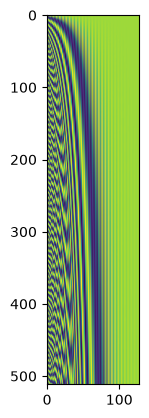

In [6]:

rope = RoPE(128)

plt.imshow(rope(torch.ones(1, 1, 512, 128)).view(512, 128))

plt.show()